In [3]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from scipy.linalg import ishermitian, eigvals, eigvalsh
from scipy.sparse import kron, eye, diags, csc_matrix, hstack, vstack, random
from scipy.sparse.linalg import expm_multiply, spsolve, norm
from utils import *
from braket.circuits import Circuit

from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.quantum_info import SparsePauliOp, Operator
from qiskit.synthesis import LieTrotter, SuzukiTrotter
from qiskit import transpile
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.circuit.library import QFT
# from ionq_circuit_utils import save_as_native_circuit

from pytket import OpType
from pytket.passes import RemoveRedundancies, CommuteThroughMultis, RepeatPass, SequencePass, FullPeepholeOptimise, auto_rebase_pass
from pytket.extensions.qiskit import qiskit_to_tk

# Schrodingerization implementation

Lemma.
Let $N = 2^n$ for $n\geq 1$.
Let $H_d = \mathrm{diag}(0,1,\dots,N/2-1,-N/2,-N/2+1,\dots,-1)$. Then $H_d$ can be decomposed as
$$
    H_d = -\frac{1}{2}\left(I - 2^{n} Z_n + \sum_{j=1}^{n} 2^{j-1} Z_j \right).
$$
Proof.

For any computational basis state $\ket{k}$ (the integer $k$ expressed as a binary bit string), let $q_i\in\{0,1\}$ be the value of the $i$-th bit.
Then $k=\sum_{i=1}^{n} 2^{i-1} q_{i}$.
Therefore,
$$
    \bra{k} \sum_{j=1}^{n} 2^{j-1} Z_j \ket{k} = \sum_{j=1}^{n} 2^{j-1} (1 - 2q_j) = 2^{n} - 1 - 2k.
$$
Then
$$
    \bra{k} H_d \ket{k} =
    \begin{cases}
        k &\qquad\text{if $k \leq N/2-1$,}\\
        k-N &\qquad\text{if $k \geq N/2$.}
    \end{cases}
$$

In [20]:
def schrodingerization(A, u_0, N, L, R, T, N_t, lambda_min, r=None):
    dimension = u_0.shape[0]
    h = (R - L) / (N - 1)
    # Convert ODE to PDE
    H1 = (A + np.conj(A).T) / 2
    print("Eigvals of H1:", eigvalsh(H1.toarray()))
    # assert np.alltrue(np.linalg.eigvalsh(H1) <= 0)
    H2 = (A - np.conj(A).T) / 2j
    # print("H1:", H1.toarray())
    # print("H2:", H2.toarray())

    p_vals = np.linspace(L, R, N)
    v_0 = kron(u_0, np.exp(-np.abs(p_vals))).toarray().flatten() # second axis is for p
    # Write out the Hamiltonian
    # centered differences
    H = 1j * (- kron(H1, (1 / (2 * h)) * diags([np.ones(N-1), -np.ones(N-1)], offsets=[1,-1])) + 1j * kron(H2, eye(N)))
    # Solve the PDE
    v = expm_multiply(-1j * H, v_0, start=0, stop=T, num=N_t).real

    # One issue: how to recover the amplitudes? (need to take absolute value?)
    # u_recover = np.sum(np.abs(np.reshape(v, newshape=(N_t, dimension, N))[:,:,N//2:]), axis=2) * h

    u_recover = np.zeros((N_t, dimension))
    for i, t in enumerate(np.linspace(0, T, N_t)):
        a = -lambda_min * t
        a_idx = int((a - L) / h)
        # u_recover[i] = np.exp(a) * np.sum(np.reshape(v, newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
        u_recover[i] = np.exp(a) * np.sum(np.reshape(np.abs(v), newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
    
    return u_recover

def schrodingerization_ft(A, u_0, N, L, R, T, N_t, lambda_min, r=None):
    dimension = u_0.shape[0]
    h = (R - L) / (N - 1)
    # Convert ODE to PDE
    H1 = (A + np.conj(A).T) / 2
    print("Eigvals of H1:", eigvalsh(H1.toarray()))
    # assert np.alltrue(np.linalg.eigvalsh(H1) <= 0)
    H2 = (A - np.conj(A).T) / 2j
    # print("H1:", H1.toarray())
    # print("H2:", H2.toarray())
    p = np.linspace(L, R, N)
    v_0 = kron(u_0, np.fft.fft(np.exp(-np.abs(p)), norm="ortho")).toarray().flatten() # second axis is for p
    # v_0 = kron(u_0, np.sqrt(2 / np.pi) / (xi ** 2 + 1)).toarray().flatten() # second axis is for p
    # Write out the Hamiltonian
    H = - (kron(H1, -diags(np.fft.fftfreq(N, d = 1/(N * 2 * np.pi / (R - L))))) + kron(H2, eye(N)))
    print(H.shape)
    # Solve the PDE
    v = expm_multiply(-1j * H, v_0, start=0, stop=T, num=N_t)
    
    IFFT = np.fft.ifft(np.eye(N), N, norm="ortho")
    v = ((kron(np.eye(dimension), IFFT) @ v.T).real).T
    
    # Issue: how to recover the amplitudes? (need to take absolute value?)
    u_recover = np.zeros((N_t, dimension))
    for i, t in enumerate(np.linspace(0, T, N_t)):
        a = -lambda_min * t
        a_idx = int((a - L) / h)
        # u_recover[i] = np.exp(a) * np.sum(np.reshape(v, newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
        u_recover[i] = np.exp(a) * np.sum(np.reshape(np.abs(v), newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
    

    return u_recover

def schrodingerization_ft_trot(A, u_0, N, L, R, T, N_t, lambda_min, r):
    assert type(r) == int and r >= 1
    dimension = u_0.shape[0]
    n_p = int(np.log2(N))
    h = (R - L) / (N - 1)
    # Convert ODE to PDE
    H1 = (A + np.conj(A).T) / 2
    print("Eigvals of H1:", eigvalsh(H1.toarray()))
    # assert np.alltrue(np.linalg.eigvalsh(H1) <= 0)
    H2 = (A - np.conj(A).T) / 2j
    # print("H1:", H1.toarray())
    # print("H2:", H2.toarray())
    p = np.linspace(L, R, N, dtype=np.complex128)
    v_0 = kron(u_0, np.fft.fft(np.exp(-np.abs(p)), norm="ortho")).toarray().flatten() # second axis is for p
    # v_0 = kron(u_0, np.sqrt(2 / np.pi) / (xi ** 2 + 1)).toarray().flatten() # second axis is for p
    # Write out the Hamiltonian
    H = - (kron(H1, -diags(np.fft.fftfreq(N, d = 1/(N * 2 * np.pi / (R - L))))) + kron(H2, eye(N)))
    H1_pauli_list = SparsePauliOp.from_operator(H1.toarray()).to_list()
    xi_pauli_list = SparsePauliOp.from_operator(-diags(np.fft.fftfreq(N, d = 1/(N * 2 * np.pi / (R - L)))).toarray()).to_list()
    H2_pauli_list = SparsePauliOp.from_operator(H2.toarray()).to_list()

    pauli_list = []
    for i in range(len(H1_pauli_list)):
        for j in range(len(xi_pauli_list)):
            pauli_list.append((H1_pauli_list[i][0] + xi_pauli_list[j][0], -H1_pauli_list[i][1] * xi_pauli_list[j][1]))
    for i in range(len(H2_pauli_list)):
        pauli_list.append((H2_pauli_list[i][0] + ''.join(n_p * ['I']), -H2_pauli_list[i][1]))
    pauli_op = SparsePauliOp.from_list(pauli_list)
    pauli_op_commuting = pauli_op.simplify().group_commuting()
    print(f"Norm of diff: {np.linalg.norm(pauli_op.to_matrix() - H.toarray()) : 0.2f}")

    # Hamiltonian simulation
    t_vals = np.linspace(0, T, N_t)
    v = []
    for t in t_vals:
        v_t = v_0
        dt = t / r
        for _ in range(r):
            for i in range(len(pauli_op_commuting)):
                v_t = expm_multiply(-1j * pauli_op_commuting[i].to_matrix() * dt / 2, v_t)
            for i in range(len(pauli_op_commuting))[::-1]:
                v_t = expm_multiply(-1j * pauli_op_commuting[i].to_matrix() * dt / 2, v_t)
        
        v.append(v_t)
    v = np.array(v)
    # Solve the PDE
    v_no_trot = expm_multiply(-1j * H * T, v_0)
    print(f"Trotter error: {np.linalg.norm(v[-1] - v_no_trot) : 0.2f}")
    
    IFFT = np.fft.ifft(np.eye(N), N, norm="ortho")
    v = ((kron(np.eye(dimension), IFFT) @ v.T)).T
    # Issue: how to recover the amplitudes? (need to take absolute value?)
    u_recover = np.zeros((N_t, dimension))
    for i, t in enumerate(np.linspace(0, T, N_t)):
        a = -lambda_min * t
        a_idx = int((a - L) / h)
        # u_recover[i] = np.exp(a) * np.sum(np.reshape(v, newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
        u_recover[i] = np.exp(a) * np.sum(np.reshape(np.abs(v), newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
    
    
    return u_recover


In [21]:
def solve_gradient_flow(A, b, x_0, N, L, R, T, N_t, schrodingerization_method, r=None):
    # The gradient of the optimization problem is Ax-b, so the gradient flow ODE is x'(t) = - Ax + b.
    A_tilde = vstack([hstack([A, -b]), csc_matrix((1, A.shape[0]+1))])
    # print(A_tilde.toarray())
    print("Eigvals of A_tilde: ", eigvals(A_tilde.toarray()))

    lambda_min = np.min(eigvalsh((A_tilde + A_tilde.T).toarray() / 2))
    print("Min eval:", lambda_min)
    u_recover = schrodingerization_method(-A_tilde, vstack([x_0, 1]), N, L, R, T, N_t, lambda_min=-norm(b)/2, r=r)
    return u_recover[:,:-1]


In [22]:
def get_xi_pauli_op(n_p, L, R):
    xi_pauli_list = []
    op = n_p * ['I']
    xi_pauli_list.append((''.join(op), 1))

    for i in range(n_p - 1):
        op = n_p * ['I']
        op[n_p-1-i] = 'Z'
        xi_pauli_list.append((''.join(op), 2 ** i))
    
    op = n_p * ['I']
    op[0] = 'Z'
    xi_pauli_list.append((''.join(op), - 2 ** (n_p - 1)))

    xi_pauli_op = 0.5 * (2 * np.pi / (R - L)) * SparsePauliOp.from_list(xi_pauli_list)
    return xi_pauli_op

State preparation for auxiliary variable

In [23]:
H_1 = sum_h_x(n=2, h=np.array([2, 3])) + sum_h_z(n=2, h=np.array([-5, -6]))
H_1 -= H_1[-1,-1] * eye(4)
assert H_1[-1,-1] == 0
A = -H_1[:3,:3]
A_norm = np.linalg.norm(A.toarray(), ord=2)
H_1 /= A_norm
A /= A_norm
print("A:\n", A.toarray())
evals = eigvalsh(A.toarray())
print("Eigenvalues:", evals)
print(f"Condition number: {np.max(evals) / np.min(evals)}")
assert np.all(eigvalsh(A.toarray()) > 0)
b = 2 * H_1[:-1,-1]

print("b:\n", b.toarray())
A_tilde = vstack([hstack([-A, b]), csc_matrix((1, A.shape[0]+1))])
H_2 = (A_tilde - np.conj(A_tilde).T) / 2j

x_0 = csc_matrix(np.array([[0, 0, 0]]).T)
dimension = 3

x_sol = spsolve(A, b)
print("Ground truth:", x_sol)

A:
 [[ 0.95438407 -0.08676219 -0.13014328]
 [-0.08676219  0.52057313  0.        ]
 [-0.13014328  0.          0.43381094]]
Eigenvalues: [0.39944135 0.50932679 1.        ]
Condition number: 2.5034964622559515
b:
 [[0.        ]
 [0.26028656]
 [0.17352438]]
Ground truth: [0.105939  0.5176565 0.4317817]


In [24]:
R = 6
L = -R
n_p = 6
N_p = 2 ** n_p
h = (R - L) / (N_p - 1)
n_x = int(np.log2(A_tilde.shape[0]))
print("N_p:", N_p)
print(f"Total number of qubits: {n_p + n_x}")
T = 5
N_t = 16
r = 2
u_recover = solve_gradient_flow(A, b, x_0, N_p, L, R, T, N_t, schrodingerization)
u_recover_ft = solve_gradient_flow(A, b, x_0, N_p, L, R, T, N_t, schrodingerization_ft)
u_recover_trot = solve_gradient_flow(A, b, x_0, N_p, L, R, T, N_t, schrodingerization_ft_trot, r=r)

print(f"Relative error (Schrodingerization): {np.linalg.norm(u_recover[-1,:] - x_sol) / np.linalg.norm(x_sol) : 0.3f}")
print(f"Relative error (Schrodingerization with FT): {np.linalg.norm(u_recover_ft[-1,:] - x_sol) / np.linalg.norm(x_sol) : 0.3f}")
print(f"Relative error (Schrodingerization with FT, Trotter): {np.linalg.norm(u_recover_trot[-1,:] - x_sol) / np.linalg.norm(x_sol) : 0.3f}")

N_p: 64
Total number of qubits: 8
Eigvals of A_tilde:  [1.        +0.j 0.39944135+0.j 0.50932679+0.j 0.        +0.j]
Min eval: -0.047431532222661596
Eigvals of H1: [-1.0018156  -0.53458692 -0.41979715  0.04743153]
Eigvals of A_tilde:  [1.        +0.j 0.39944135+0.j 0.50932679+0.j 0.        +0.j]
Min eval: -0.047431532222661596
Eigvals of H1: [-1.0018156  -0.53458692 -0.41979715  0.04743153]
(256, 256)
Eigvals of A_tilde:  [1.        +0.j 0.39944135+0.j 0.50932679+0.j 0.        +0.j]
Min eval: -0.047431532222661596
Eigvals of H1: [-1.0018156  -0.53458692 -0.41979715  0.04743153]
Norm of diff:  0.00
Trotter error:  0.51
Relative error (Schrodingerization):  0.095
Relative error (Schrodingerization with FT):  0.090
Relative error (Schrodingerization with FT, Trotter):  0.231


Ground truth

In [25]:
F_gf = lambda t, u: -A.toarray() @ u + b.toarray().reshape(dimension)

t_vals = np.linspace(0, T, N_t)
sol_gf = solve_ivp(F_gf, [0, T], x_0.toarray().reshape(dimension), t_eval=t_vals)

A_tilde = vstack([hstack([-A, b]), csc_matrix((1, A.shape[0]+1))])
# u_recover = schrodingerization(A_tilde, vstack([x_0, 1]), N, L, R, T, N_t, )

print(eigvals(A_tilde.toarray()))
print(eigvalsh((A_tilde + A_tilde.T).toarray() / 2))
F = lambda t, u: A_tilde @ u
t_vals = np.linspace(0, T, N_t)
sol_augmented = solve_ivp(F, [0, T], vstack([x_0, 1]).toarray().reshape(dimension+1), t_eval=t_vals)

[-1.        +0.j -0.39944135+0.j -0.50932679+0.j  0.        +0.j]
[-1.0018156  -0.53458692 -0.41979715  0.04743153]


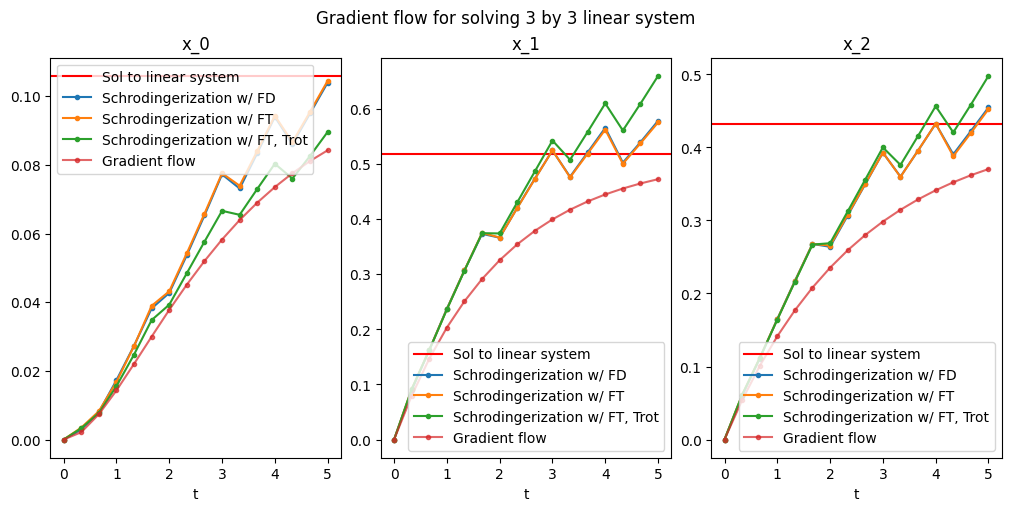

In [26]:
t_vals = np.linspace(0, T, N_t)

fig, axs = plt.subplots(1, dimension, constrained_layout=True, facecolor="white", figsize=(10,5))

aspect = 0.4

for i in range(3):
    
    axs[i].axhline(y=x_sol[i], color='red', label="Sol to linear system")

    axs[i].plot(t_vals, u_recover[:,i].real, '-o', label="Schrodingerization w/ FD", markersize=3)
    
    axs[i].plot(t_vals, u_recover_ft[:,i].real, '-o', label="Schrodingerization w/ FT", markersize=3)
    axs[i].plot(t_vals, u_recover_trot[:,i].real, '-o', label="Schrodingerization w/ FT, Trot", markersize=3)
    # axs[i].plot(t_vals, sol_augmented.y[i], '--o', label="scipy augmented ODE", linewidth=3, alpha=0.7)
    
    axs[i].plot(t_vals, sol_gf.y[i], '-o', label="Gradient flow", alpha=0.7, markersize=3)
    axs[i].legend()
    axs[i].set_title(f"x_{i}")
    axs[i].set_xlabel(f"t")
    # axs[i].set_ylim([-2, 2])
plt.suptitle(f"Gradient flow for solving {dimension} by {dimension} linear system")
plt.show()

In [69]:
def get_pauli_weight(pauli_str):
    weight = 0
    for pauli in pauli_str:
        if pauli == 'X' or pauli == 'Y' or pauli == 'Z':
            weight += 1
        else:
            assert pauli == 'I'
    return weight

def get_pauli_index(pauli_str):
    assert get_pauli_weight(pauli_str) == 1
    n = len(pauli_str)
    i = 0
    while pauli_str[n-1-i] == 'I':
        i += 1
    return i, pauli_str[n-1-i]

def pauli_to_int(pauli):
    if pauli == 'X':
        return 0
    elif pauli == 'Y':
        return 1
    elif pauli == 'Z':
        return 2
    else:
        raise ValueError("Invalid Pauli, should be one of X, Y, or Z")

In [70]:
def get_full_circuit_naive_trotter(n_x, n_p, t, H_1, H_2, r):
    N_p = 2 ** n_p
    p = np.linspace(L, R, N_p)
    amplitude_vector = np.fft.fft(np.exp(-np.abs(p)), norm="ortho")
    amplitude_vector /= np.linalg.norm(amplitude_vector)

    q = QuantumRegister(n_p)
    state_prep_circuit = QuantumCircuit(q)
    state_prep_circuit.initialize(amplitude_vector, [q[j] for j in range(n_p)])

    xi_pauli_list = get_xi_pauli_op(n_p, L, R).to_list()
    H_1_pauli_list = SparsePauliOp.from_operator(H_1.toarray()).to_list()
    H_2_pauli_list = SparsePauliOp.from_operator(H_2.toarray()).to_list()
    print(H_1_pauli_list)
    print(H_2_pauli_list)

    pauli_list = []
    for i in range(len(H_1_pauli_list)):
        for j in range(len(xi_pauli_list)):
            pauli_list.append((H_1_pauli_list[i][0] + xi_pauli_list[j][0], -H_1_pauli_list[i][1] * xi_pauli_list[j][1]))
    for i in range(len(H_2_pauli_list)):
        pauli_list.append((H_2_pauli_list[i][0] + ''.join(n_p * ['I']), -H_2_pauli_list[i][1]))

    print(pauli_list)

    pauli_op = SparsePauliOp.from_list(pauli_list)
    # trot_circuit = LieTrotter(reps=r).synthesize(PauliEvolutionGate(pauli_op.group_commuting()))
    trot_circuit = SuzukiTrotter(order=2, reps=r).synthesize(PauliEvolutionGate((t * pauli_op).group_commuting()))

    full_circuit = QuantumCircuit(n_p + n_x)
    full_circuit.append(state_prep_circuit, qargs=range(n_p))
    # Initial state for x register is [0,0,...,0,1]
    for i in np.arange(n_p, n_p + n_x):
        full_circuit.x(i)

    full_circuit.append(trot_circuit, qargs=range(n_p+n_x))
    full_circuit.append(QFT(n_p), qargs=range(n_p))

    return full_circuit

In [76]:
get_full_circuit(n_x, n_p, T, H_1, H_2, r)

[[[-0.02271429  0.          0.05678572]
  [-0.03407143  0.          0.06814286]]

 [[-0.04542858  0.          0.11357144]
  [-0.06814286  0.          0.13628573]]

 [[-0.09085715  0.          0.22714288]
  [-0.13628573  0.          0.27257145]]

 [[-0.1817143   0.          0.45428576]
  [-0.27257145  0.          0.54514291]]

 [[-0.3634286   0.          0.90857151]
  [-0.54514291  0.          1.09028581]]

 [[ 0.72685721  0.         -1.81714302]
  [ 1.09028581  0.         -2.18057163]]]


In [75]:
def get_full_circuit(n_x, n_p, t, H_1, H_2, r):
    N_p = 2 ** n_p
    p = np.linspace(L, R, N_p)
    amplitude_vector = np.fft.fft(np.exp(-np.abs(p)), norm="ortho")
    amplitude_vector /= np.linalg.norm(amplitude_vector)

    q = QuantumRegister(n_p)
    state_prep_circuit = QuantumCircuit(q)
    state_prep_circuit.initialize(amplitude_vector, [q[j] for j in range(n_p)])

    xi_pauli_list = get_xi_pauli_op(n_p, L, R).to_list()
    H_1_pauli_list = SparsePauliOp.from_operator(H_1.toarray()).to_list()
    H_2_pauli_list = SparsePauliOp.from_operator(H_2.toarray()).to_list()
    # print(H_1_pauli_list)
    # print(H_2_pauli_list)

    pauli_list = []
    trot_circuit = QuantumCircuit(n_p + n_x)
    dt = t / r

    # Store the coefficients in an array
    pauli_coeffs = np.zeros((n_p, n_x, 3))
    for i in range(len(H_1_pauli_list)):
        if get_pauli_weight(H_1_pauli_list[i][0]) == 1:
            # Figure out index and which Pauli operator for H_1
            H_1_index, H_1_pauli = get_pauli_index(H_1_pauli_list[i][0])

            for j in range(len(xi_pauli_list)):
                if get_pauli_weight(xi_pauli_list[j][0]) == 1:
                    xi_index, xi_pauli = get_pauli_index(xi_pauli_list[j][0])
                    assert xi_pauli == 'Z'
                    pauli_coeffs[xi_index, H_1_index, pauli_to_int(H_1_pauli)] = (-H_1_pauli_list[i][1] * xi_pauli_list[j][1]).real
    print(pauli_coeffs)

    # First-order Trotter
    
    # Second-order Trotter
    # for _ in range(r):
    #     # Forwards
    #     for i in range(len(H_1_pauli_list)):
    #         for j in range(len(xi_pauli_list)):
    #             weight = get_pauli_weight(H_1_pauli_list[i][0] + xi_pauli_list[j][0])
    #             if weight == 1:
    #                 trot_circuit.append(, qargs=list(range(n_p+n_x)))
    #             elif weight == 2:
                    
    #             elif weight > 2:
    #                 raise Exception(f"Pauli string is {H_1_pauli_list[i][0] + xi_pauli_list[j][0]}, only 1- and 2-local operators implemented")
    #             print(H_1_pauli_list[i][0] + xi_pauli_list[j][0])
    #             pauli_list.append((H_1_pauli_list[i][0] + xi_pauli_list[j][0], -H_1_pauli_list[i][1] * xi_pauli_list[j][1]))
    #     for i in range(len(H_2_pauli_list)):
    #         pauli_list.append((H_2_pauli_list[i][0] + ''.join(n_p * ['I']), -H_2_pauli_list[i][1]))

    #     # Backwards
    #     for i in range(len(H_2_pauli_list))[::-1]:
    #         pauli_list.append((H_2_pauli_list[i][0] + ''.join(n_p * ['I']), -H_2_pauli_list[i][1]))
    #     for i in range(len(H_1_pauli_list))[::-1]:
    #         for j in range(len(xi_pauli_list))[::-1]:
    #             weight = get_pauli_weight(H_1_pauli_list[i][0] + xi_pauli_list[j][0])
    #             if weight == 1:
                
    #             elif weight == 2:
                    
    #             elif weight > 2:
    #                 raise Exception(f"Pauli string is {H_1_pauli_list[i][0] + xi_pauli_list[j][0]}, only 2-local operators implemented for now")
    #             print(H_1_pauli_list[i][0] + xi_pauli_list[j][0])
    #             pauli_list.append((H_1_pauli_list[i][0] + xi_pauli_list[j][0], -H_1_pauli_list[i][1] * xi_pauli_list[j][1]))
  

    # pauli_op = SparsePauliOp.from_list(pauli_list)
    # # trot_circuit = LieTrotter(reps=r).synthesize(PauliEvolutionGate(pauli_op.group_commuting()))
    # # trot_circuit = SuzukiTrotter(order=2, reps=r).synthesize(PauliEvolutionGate((t * pauli_op).group_commuting()))

    # full_circuit = QuantumCircuit(n_p + n_x)
    # full_circuit.append(state_prep_circuit, qargs=range(n_p))
    # # Initial state for x register is [0,0,...,0,1]
    # for i in np.arange(n_p, n_p + n_x):
    #     full_circuit.x(i)

    # full_circuit.append(trot_circuit, qargs=range(n_p+n_x))
    # full_circuit.append(QFT(n_p), qargs=range(n_p))

    # return full_circuit

In [53]:
pauli_list = [('YZ', 1)]
pauli_op = SparsePauliOp.from_list(pauli_list)
# trot_circuit = LieTrotter(reps=r).synthesize(PauliEvolutionGate(pauli_op.group_commuting()))
trot_circuit = SuzukiTrotter(order=2, reps=1).synthesize(PauliEvolutionGate((pauli_op).group_commuting()))
transpiled_circuit = transpile(trot_circuit, basis_gates=["rx", "ry", "rz", "rxx"], optimization_level=2)
print(transpiled_circuit)

global phase: π/2
                         ┌───────────┐┌──────────┐┌───────┐┌───────────┐»
q_0: ────────────────────┤1          ├┤ Rx(-π/2) ├┤ Rz(2) ├┤1          ├»
     ┌─────────┐┌───────┐│  Rxx(π/2) │├──────────┤└───────┘│  Rxx(π/2) │»
q_1: ┤ Rz(π/2) ├┤ Ry(π) ├┤0          ├┤ Rx(-π/2) ├─────────┤0          ├»
     └─────────┘└───────┘└───────────┘└──────────┘         └───────────┘»
«     ┌──────────┐           
«q_0: ┤ Rx(-π/2) ├───────────
«     ├─────────┬┘┌─────────┐
«q_1: ┤ Rz(π/2) ├─┤ Ry(π/2) ├
«     └─────────┘ └─────────┘


In [54]:
get_full_circuit(n_x, n_p, T, H_1, H_2, r)

[('II', (-0.47719203552864675+0j)), ('IX', (0.08676218827793578+0j)), ('IZ', (-0.21690547069483945+0j)), ('XI', (0.13014328241690365+0j)), ('ZI', (-0.2602865648338073+0j))]
[('IY', (0.04338109413896789+0j)), ('YI', (0.06507164120845182+0j)), ('YZ', (-0.06507164120845182+0j)), ('ZY', (-0.04338109413896789+0j))]
0
IIIIIIII
1
IIIIIIIZ
1
IIIIIIZI
1
IIIIIZII
1
IIIIZIII
1
IIIZIIII
1
IIZIIIII
1
IXIIIIII
2
IXIIIIIZ
2
IXIIIIZI
2
IXIIIZII
2
IXIIZIII
2
IXIZIIII
2
IXZIIIII
1
IZIIIIII
2
IZIIIIIZ
2
IZIIIIZI
2
IZIIIZII
2
IZIIZIII
2
IZIZIIII
2
IZZIIIII
1
XIIIIIII
2
XIIIIIIZ
2
XIIIIIZI
2
XIIIIZII
2
XIIIZIII
2
XIIZIIII
2
XIZIIIII
1
ZIIIIIII
2
ZIIIIIIZ
2
ZIIIIIZI
2
ZIIIIZII
2
ZIIIZIII
2
ZIIZIIII
2
ZIZIIIII
[('IIIIIIII', (0.12492858276402967+0j)), ('IIIIIIIZ', (0.12492858276402967+0j)), ('IIIIIIZI', (0.24985716552805934+0j)), ('IIIIIZII', (0.4997143310561187+0j)), ('IIIIZIII', (0.9994286621122374+0j)), ('IIIZIIII', (1.9988573242244747+0j)), ('IIZIIIII', (-3.9977146484489494+0j)), ('IXIIIIII', (-0.02271428

In [81]:
# T = 0


# H_1 = 2 * (sum_h_x(n=2, h=np.array([-1, 1])) + sum_h_z(n=2, h=np.array([1, 1])) + 2 * eye(4))
# print("H_1:\n", H_1.toarray())
# assert H_1[-1,-1] == 0
# A = H_1[:3,:3]
# print("A:\n", A.toarray())
# print(eigvalsh(A.toarray()))
# assert np.all(eigvalsh(A.toarray()) > 0)
# b = -2 * H_1[:-1,-1]
# print("b:\n", b.toarray())
# A_tilde = vstack([hstack([-A, b]), csc_matrix((1, A.shape[0]+1))])
# H_2 = (A_tilde - np.conj(A_tilde).T) / 2j

# x_0 = csc_matrix(np.array([[0, 0, 0]]).T)
# dimension = 3

# x_sol = spsolve(A, b)
# print("Ground truth:", x_sol)

# # The gradient of the optimization problem is Ax-b, so the gradient flow ODE is x'(t) = - Ax + b.
# A_tilde = vstack([hstack([A, -b]), csc_matrix((1, A.shape[0]+1))])
# # print(A_tilde.toarray())
# print("Eigvals of A_tilde: ", eigvals(A_tilde.toarray()))

# lambda_min = np.min(eigvalsh((A_tilde + A_tilde.T).toarray() / 2))
# print("Min eval:", lambda_min)
# A = -A_tilde
# u_0 = vstack([x_0, 1])
# lambda_min=-norm(b)/2

# dimension = u_0.shape[0]
# n_p = int(np.log2(N_p))
# h = (R - L) / (N_p - 1)
# # Convert ODE to PDE
# H1 = (A + np.conj(A).T) / 2
# print("Eigvals of H1:", eigvalsh(H1.toarray()))
# # assert np.alltrue(np.linalg.eigvalsh(H1) <= 0)
# H2 = (A - np.conj(A).T) / 2j
# # print("H1:", H1.toarray())
# # print("H2:", H2.toarray())
# p = np.linspace(L, R, N_p)
# v_0 = kron(u_0, np.fft.fft(np.exp(-np.abs(p)), norm="ortho")).toarray().flatten() # second axis is for p
# v_0 /= np.linalg.norm(v_0)
# N = N_p


# H = - (kron(H1, -diags(np.fft.fftfreq(N, d = 1/(N * 2 * np.pi / (R - L))))) + kron(H2, eye(N)))
# v_no_trot = expm_multiply(-1j * H * T, v_0)
# IFFT = np.fft.ifft(np.eye(N), N, norm="ortho")
# v = kron(np.eye(dimension), IFFT) @ v_no_trot

In [82]:
# r = 100

# circuit = get_full_circuit(n_x, n_p, T, H_1, H_2, r)
# compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rzx'], optimization_level=2)

# backend = Aer.get_backend('statevector_simulator')
# job = backend.run(compiled_circuit)
# result = job.result()
# output_state = np.array(result.get_statevector(compiled_circuit))

In [83]:
p = np.linspace(L, R, N_p)
amplitude_vector = np.fft.fft(np.exp(-np.abs(p)), norm="ortho")
normalization_factor = np.linalg.norm(amplitude_vector)

u_recover_circ = np.zeros((N_t, dimension))
for i, t in enumerate(t_vals):
    print(f"Running t ={t : 0.2f}")
    circuit = get_full_circuit(n_x, n_p, t, H_1, H_2, r)
    compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rzx'], optimization_level=2)
    # print("Depth:", compiled_circuit.depth())
    # print(compiled_circuit.count_ops())

    # Run the quantum circuit on a statevector simulator backend
    backend = Aer.get_backend('statevector_simulator')
    job = backend.run(compiled_circuit)
    result = job.result()
    output_state = np.array(result.get_statevector(compiled_circuit))
    output_state *= (-1j)
    # print(output_state)

    lambda_min = -norm(b)/2
    a = -lambda_min * t
    a_idx = int((a - L) / h)
    # u_recover[i] = np.exp(a) * np.sum(np.reshape(v, newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
    u_recover_circ[i] = (normalization_factor * np.exp(a) * np.sum(np.reshape(np.abs(output_state), newshape=(dimension + 1, N_p))[:,a_idx:], axis=1) * h)[:-1].real


Running t = 0.00
Running t = 0.33
Running t = 0.67
Running t = 1.00
Running t = 1.33
Running t = 1.67
Running t = 2.00
Running t = 2.33
Running t = 2.67
Running t = 3.00
Running t = 3.33
Running t = 3.67
Running t = 4.00
Running t = 4.33
Running t = 4.67
Running t = 5.00


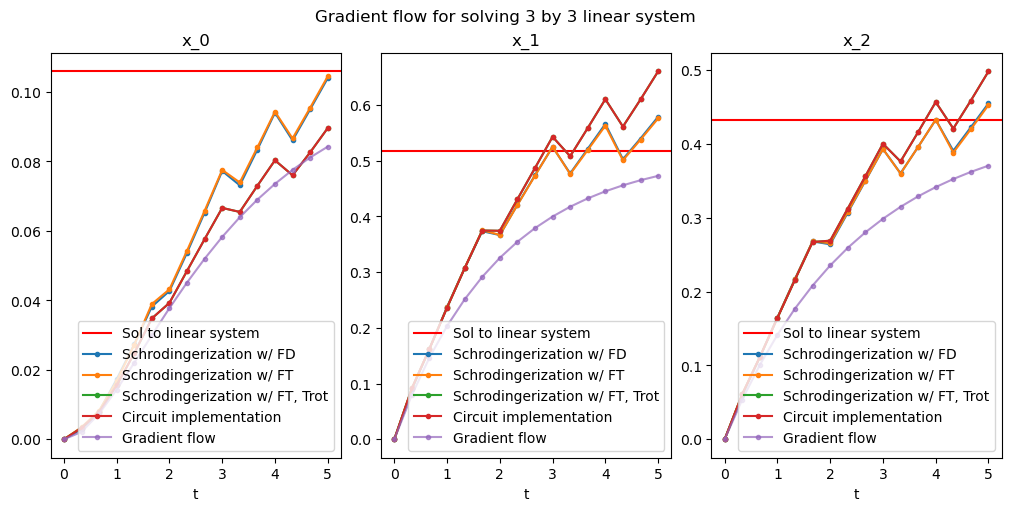

In [84]:
t_vals = np.linspace(0, T, N_t)

fig, axs = plt.subplots(1, dimension, constrained_layout=True, facecolor="white", figsize=(10,5))

aspect = 0.4

for i in range(3):
    
    axs[i].axhline(y=x_sol[i], color='red', label="Sol to linear system")

    axs[i].plot(t_vals, u_recover[:,i].real, '-o', label="Schrodingerization w/ FD", markersize=3)
    
    axs[i].plot(t_vals, u_recover_ft[:,i].real, '-o', label="Schrodingerization w/ FT", markersize=3)
    axs[i].plot(t_vals, u_recover_trot[:,i].real, '-o', label="Schrodingerization w/ FT, Trot", markersize=3)
    # axs[i].plot(t_vals, sol_augmented.y[i], '--o', label="scipy augmented ODE", linewidth=3, alpha=0.7)
    axs[i].plot(t_vals, u_recover_circ[:,i].real, '-o', label="Circuit implementation", markersize=3)
    
    axs[i].plot(t_vals, sol_gf.y[i], '-o', label="Gradient flow", alpha=0.7, markersize=3)
    axs[i].legend()
    axs[i].set_title(f"x_{i}")
    axs[i].set_xlabel(f"t")
    # axs[i].set_ylim([-2, 2])
plt.suptitle(f"Gradient flow for solving {dimension} by {dimension} linear system")
plt.show()

In [89]:
circuit = get_full_circuit(n_x, n_p, t, H_1, H_2, r)
compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx'], optimization_level=2)
print("Depth:", compiled_circuit.depth())
print(compiled_circuit.count_ops())

# tket_circuit = qiskit_to_tk(compiled_circuit)
# gateset = {OpType.Rx, OpType.Ry, OpType.Rz, OpType.XXPhase}
# rebase = auto_rebase_pass(gateset) 
# comp = SequencePass([FullPeepholeOptimise(), CommuteThroughMultis(), RemoveRedundancies(), rebase])
# comp.apply(tket_circuit)
# num_single_qubit_gates, num_two_qubit_gates = tket_circuit.n_1qb_gates(), tket_circuit.n_2qb_gates()
# print(num_single_qubit_gates, num_two_qubit_gates)

Depth: 552
OrderedDict([('rxx', 289), ('rx', 228), ('rz', 176), ('ry', 110)])


In [90]:
circuit = get_full_circuit(n_x, n_p, T, H_1, H_2, r)
compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx'], optimization_level=2)

In [88]:
filename = "schrodingerization_std_binary.qasm"
save_as_native_circuit(filename, compiled_circuit)